# Cross-Model Activation Patching

Activation patching is normally a same-model operation: you collect hidden states from one run of a model and patch them into another run of the **same** model. But the machinery has a natural extension — collect activations from a **source model** and patch them into a different **target model**. This is called cross-model patching.

Cross-model patching enables several experiment types:
- **Checkpoint comparison** — patch activations from an early training checkpoint into a later one to see which representations are stable
- **Model comparison** — test whether the representation of a causal variable in model A can drive behavior in model B
- **Architecture probes** — test alignment of internal representations between differently trained models

**Constraint:** Both models must share the same hidden dimension. Mismatched architectures will fail at patching time.

## Validation goal

The simplest cross-model experiment is a sanity check: when `source_pipeline == pipeline` (same checkpoint for source and target), the cross-model result must be **identical** to standard single-model patching. This notebook:

1. Runs standard single-model tracing with `source_pipeline=None`
2. Runs cross-model tracing with `source_pipeline=pipeline` (same model)
3. Confirms the outputs are cell-for-cell identical
4. Shows how to scale this to a full population-level cross-model `locate` scan

In [1]:
# PARAMETERS
MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct"
MAX_NEW_TOKENS = 1

import torch
from causalab.neural.pipeline import LMPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16 if device == "cuda" else torch.float32

pipeline = LMPipeline(
    MODEL_NAME,
    max_new_tokens=MAX_NEW_TOKENS,
    device=device,
    dtype=dtype,
)

# For cross-model validation: source and target are the same checkpoint
source_pipeline = pipeline

print(f"Target model loaded on {pipeline.model.device}")
print("Source model: same as target (validation scenario)")

Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/.no_exist/9213176726f574b556790deb65791e0c5aa438b6/custom_generate/generate.py'


Target model loaded on cuda:0
Source model: same as target (validation scenario)


## Constructing a counterfactual pair

We reuse the same MCQA setup from notebook 02: a multiple-choice question where the causal variable we want to trace is the label symbol (A/B/C) attached to the correct answer. The counterfactual changes exactly that symbol, so the two prompts differ in one position of the input text.

In [2]:
import random
from causalab.tasks.MCQA.causal_models import positional_causal_model
from causalab.tasks.MCQA.counterfactuals import sample_answerable_question

causal_model = positional_causal_model


def checker(neural_output, causal_output):
    return (
        causal_output.strip() in neural_output["string"].strip()
        or neural_output["string"].strip() in causal_output.strip()
    )


while True:
    original = sample_answerable_question()
    cf_inputs = {var: original[var] for var in causal_model.inputs}
    answer_symbol_key = f"symbol{original['answer_position']}"
    new_symbols = list({"A", "B", "C"}.difference({original[answer_symbol_key]}))
    cf_inputs[answer_symbol_key] = random.choice(new_symbols)
    counterfactual = causal_model.new_trace(cf_inputs)

    orig_pred = pipeline.generate([original])
    cf_pred = pipeline.generate([counterfactual])

    if checker(orig_pred, original["raw_output"]) and checker(cf_pred, counterfactual["raw_output"]):
        break

print("Original:")
print(f"  prompt:     {original['raw_input'].strip()}")
print(f"  prediction: {orig_pred['string'].strip()!r}   expected: {original['raw_output'].strip()!r}")
print()
print("Counterfactual:")
print(f"  prompt:     {counterfactual['raw_input'].strip()}")
print(f"  prediction: {cf_pred['string'].strip()!r}   expected: {counterfactual['raw_output'].strip()!r}")

Original:
  prompt:     The house is yellow. What color is the house?
R. pink
B. yellow
Answer:
  prediction: 'B'   expected: 'B'

Counterfactual:
  prompt:     The house is yellow. What color is the house?
R. pink
C. yellow
Answer:
  prediction: 'C'   expected: 'C'


## Single-model tracing (baseline)

We first run standard single-model patching: activations are collected from `pipeline` and patched back into `pipeline`. This is the control condition. `source_pipeline=None` (the default) means the same pipeline provides both the source activations and receives the interventions.

In [ ]:
# PARAMETERS
LAYERS = None  # None = all layers including the embedding layer

from causalab.methods.interchange.single_pair import run_single_pair_trace
from causalab.neural.token_positions import get_list_of_each_token

token_positions = get_list_of_each_token(original["raw_input"], pipeline)
print(f"Token positions ({len(token_positions)}): {[tp.id for tp in token_positions]}")

# Standard patching: collect activations from pipeline, patch into pipeline
single_model_result = run_single_pair_trace(
    pipeline=pipeline,
    prompt=original["raw_input"],
    counterfactual_prompt=counterfactual["raw_input"],
    token_positions=token_positions,
    layers=LAYERS,
    verbose=True,
    source_pipeline=None,  # standard single-model patching
)
print(f"\nSingle-model: collected {len(single_model_result['intervention_results'])} intervention results")

## Cross-model tracing with the same model

Now we explicitly set `source_pipeline=pipeline` — the same object as the target. This exercises the cross-model code path while guaranteeing the result must be identical to the single-model baseline above. It is the minimal validation of the implementation.

In [ ]:
# Cross-model with source == target: should produce identical outputs
cross_model_result = run_single_pair_trace(
    pipeline=pipeline,
    prompt=original["raw_input"],
    counterfactual_prompt=counterfactual["raw_input"],
    token_positions=token_positions,
    layers=LAYERS,
    verbose=True,
    source_pipeline=source_pipeline,  # explicit cross-model with identical checkpoint
)
print(f"\nCross-model (same): collected {len(cross_model_result['intervention_results'])} intervention results")

## Validation: comparing cell-for-cell outputs

For every (layer, token_position) cell, the single-model and cross-model runs should produce the same output token. Any mismatch would indicate a bug in the cross-model activation collection.

In [5]:
all_match = True
mismatches = []

for (layer, pos_id), single_res in single_model_result["intervention_results"].items():
    cross_res = cross_model_result["intervention_results"].get((layer, pos_id))
    if cross_res is None:
        all_match = False
        mismatches.append(f"Missing key: layer={layer}, pos={pos_id}")
        continue

    single_out = single_res["string"][0].strip() if single_res.get("string") else ""
    cross_out = cross_res["string"][0].strip() if cross_res.get("string") else ""

    if single_out != cross_out:
        all_match = False
        mismatches.append(f"layer={layer}, pos={pos_id}: single={single_out!r} vs cross={cross_out!r}")

n_cells = len(single_model_result["intervention_results"])
if all_match:
    print(f"SUCCESS: all {n_cells} cells match between single-model and cross-model runs.")
else:
    print(f"FAILURE: {len(mismatches)} mismatches out of {n_cells} cells:")
    for m in mismatches[:10]:
        print(f"  {m}")

SUCCESS: all 374 cells match between single-model and cross-model runs.


## Visualizing both traces

We build `trace_data` dicts from both results — the same two-step pattern used in notebook 02 — and render heatmaps side-by-side. The two heatmaps must be visually identical.

Single-model heatmap:


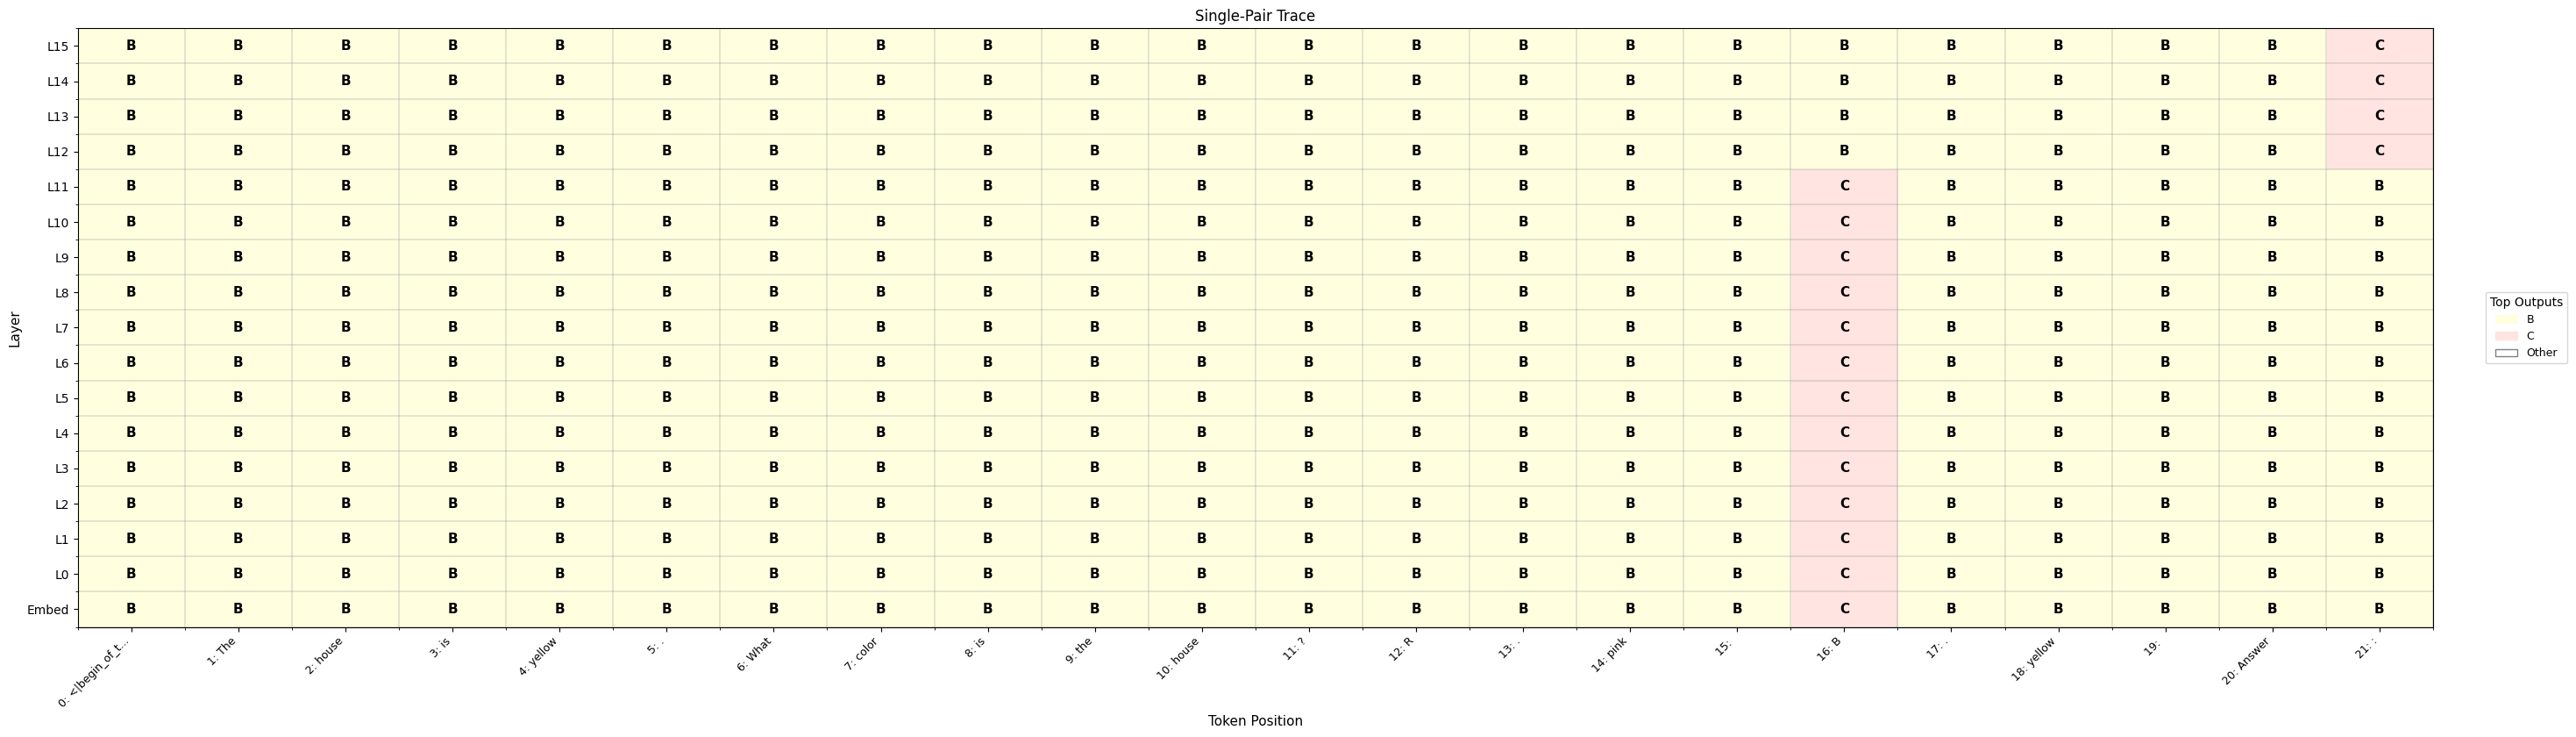


Cross-model heatmap (should be identical):


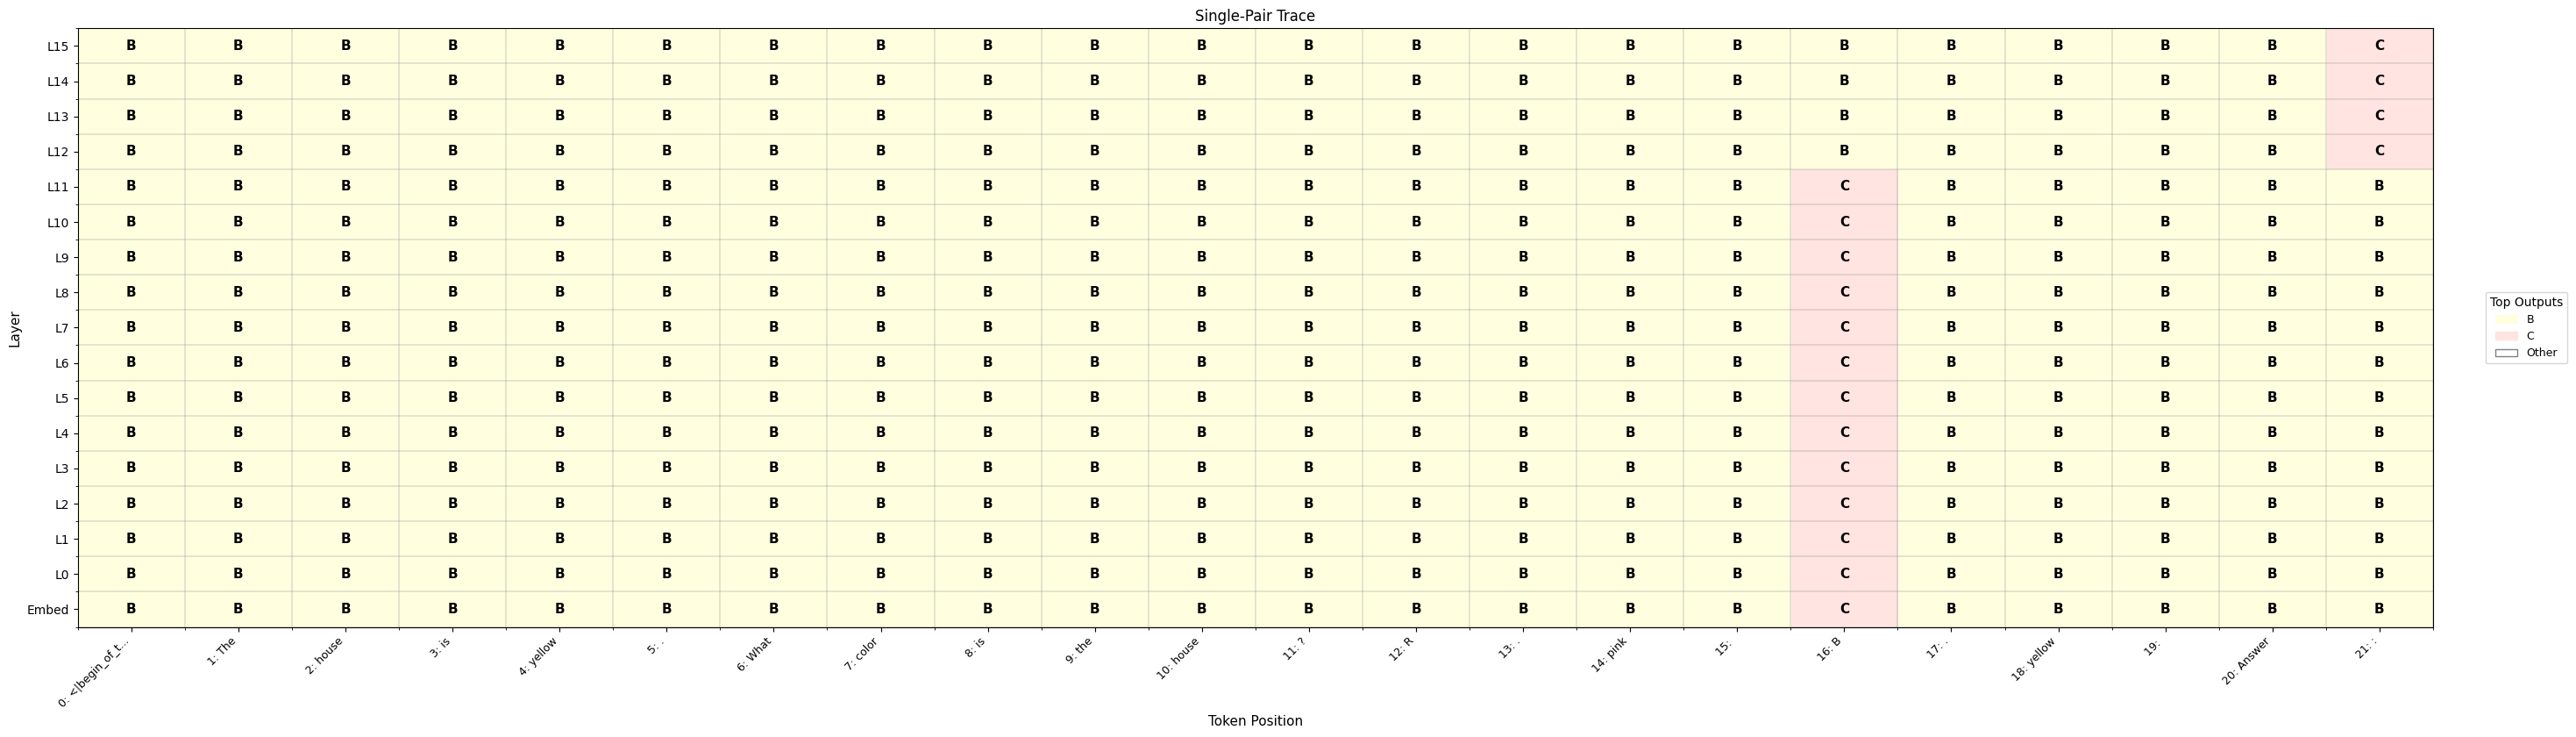

In [6]:
from causalab.io.plots.string_heatmap import build_token_labels, plot_single_pair_trace_heatmap

layers_used = single_model_result["metadata"]["layers_used"]
token_labels = build_token_labels(pipeline, original["raw_input"], token_positions)
token_position_ids = [tp.id for tp in token_positions]


def build_trace_data(result, prompt, cf_prompt, layers_used, token_position_ids, token_labels):
    cells = {}
    for (layer, pos_id), res in result["intervention_results"].items():
        output_str = res["string"][0].strip() if res.get("string") else ""
        cells[f"{layer}|{pos_id}"] = {"output": output_str}
    return {
        "prompt": prompt,
        "counterfactual_prompt": cf_prompt,
        "layers": layers_used,
        "token_position_ids": token_position_ids,
        "token_labels": token_labels,
        "cells": cells,
    }


trace_data_single = build_trace_data(
    single_model_result, original["raw_input"], counterfactual["raw_input"],
    layers_used, token_position_ids, token_labels,
)

trace_data_cross = build_trace_data(
    cross_model_result, original["raw_input"], counterfactual["raw_input"],
    layers_used, token_position_ids, token_labels,
)

print("Single-model heatmap:")
plot_single_pair_trace_heatmap(trace_data_single, figure_format="png")

print("\nCross-model heatmap (should be identical):")
plot_single_pair_trace_heatmap(trace_data_cross, figure_format="png")

## What to look for

The two heatmaps should be visually identical — the cross-model machinery is working correctly if:

- **Same token colors:** The colored cells at each (layer, token_position) are the same in both plots
- **Same signal routing:** If the answer symbol token lights up in early layers and the last-token position lights up in final layers, that pattern appears in both
- **Validation confirmation:** The comparison cell above should print `SUCCESS` with zero mismatches

Rerun the notebook with different input pairs (by re-sampling `sample_answerable_question`) to see that the consistency holds across examples. The validation is only as strong as the number of pairs you test.

When you're ready to try a **genuine** cross-model experiment, load a second model (same hidden dimension) as the `source_pipeline` and repeat. Only the config line changes — the rest of the notebook is identical.

---

## From exploration to analysis

The cross-model patching above answers a question about *one* counterfactual pair. A research question lives at the level of populations: **across all inputs, which (layer, token_position) cell most reliably encodes the causal variable in a way that transfers from a source model to a target model?** Answering that requires:

- Repeating the experiment over many base/counterfactual pairs
- Aggregating the outputs into a single score per cell
- Running with a versioned, reproducible configuration
- Saving artifacts for downstream analyses (`subspace`, `activation_manifold`)

This is exactly what the **`locate` analysis** does. Under the hood it calls the same `run_single_pair_trace` and `plot_single_pair_trace_heatmap` you just wrote — packaged behind a Hydra config that becomes the single source of truth for every parameter.

Section 2 goes further: it runs a **real cross-model `locate` scan** by setting `source_model:` in the Hydra config. Features and centroids are collected from the source model; patching is applied to the target model. The heatmap then answers: which (layer, token_position) cell encodes the causal variable in a way that transfers between models?

**Note on pairwise mode:** `mode: pairwise` is not supported for cross-model scans — it raises `ValueError` when `source_model` is set. Use `mode: centroid` for all cross-model scans.

## Running `locate` end-to-end (cross-model)

The config below is a complete runner preset. Edit any field and re-run the cell to update the config file.

| Field | What it controls |
|---|---|
| `method` | `interchange` (activation patching) or `dbm_binary` (learned binary masks) |
| `mode` | `centroid` scores each cell by KL distance to per-class reference distributions; `pairwise` checks whether patching causes the model to output the counterfactual's exact answer — **`pairwise` is not supported with `source_model`** |
| `source_model` | Model whose activations are collected; set to `null` for standard single-model patching |
| `layers` | Which layers to scan; `null` scans all |
| `n_steer` | Number of examples per class used to compute class centroids (centroid mode only) |
| `enumerate_all` | Set to `true` to use every possible input rather than sampling |
| `task.resample_variable` | Controls counterfactual generation: `all` means independent resampling (correct with `mode: centroid`); a variable name means single-variable perturbation (required for `mode: pairwise`) |

In [7]:
config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: MCQA
  - /model: llama32_1b_instruct
  - /analysis/locate
  - _self_
task:
  enumerate_all: true  # use all possible MCQA inputs
  target_variable: answer

locate:
  method: interchange
  mode: centroid  # centroid works correctly with resample_variable: all; required for cross-model
  source_model: meta-llama/Llama-3.2-1B-Instruct  # collect activations from this model, patch into target above
  layers: [0, 4, 8, 12, 15]
  n_steer: 32
  visualization:
    figure_format: png
"""

In [8]:
from omegaconf import OmegaConf
from causalab.io.configs import save_runner_config, load_runner_config

path = save_runner_config(config_yaml, "cross_model_patch_demo")
print(f"Written to {path}\n")

cfg = load_runner_config("cross_model_patch_demo")
print("Full hydra config:")
print(OmegaConf.to_yaml(cfg))

Written to causalab/configs/runners/demos/cross_model_patch_demo.yaml

Full hydra config:
seed: 42
experiment_root: artifacts/${task.name}/${model.id}
slurm:
  time: 04:00:00
task:
  name: MCQA
  intervention_metric: string_match
  max_new_tokens: 1
  colormap: viridis
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  target_variable: answer
model:
  id: llama32_1b_instruct
  name: meta-llama/Llama-3.2-1B-Instruct
  device: auto
  dtype: bfloat16
  slurm:
    gpus: 1
locate:
  _name_: locate
  _subdir: ${.method}
  _output_dir: ${experiment_root}/locate/${._subdir}
  method: interchange
  batch_size: 32
  layers:
  - 0
  - 4
  - 8
  - 12
  - 15
  token_positions: null
  component: residual_stream
  mode: centroid
  n_steer: 32
  source_model: meta-llama/Llama-3.2-1B-Instruct
  visualization:
    figure_format: png
    single_pair_trace: true
  dbm:
    training_epoch: 20
    lr: 0.001
    regularization_coefficient: 100



Run the analysis via `scripts/run_exp.sh`. This is the same entry point used from the command line.

In [9]:
import os
import subprocess
import causalab

project_root = os.path.dirname(os.path.dirname(causalab.__file__))

rc = subprocess.run(
    ["bash", "scripts/run_exp.sh", "cross_model_patch_demo"],
    cwd=project_root,
)
if rc.returncode != 0:
    raise Exception(f"Experiment failed with return code {rc.returncode}")

[2026-05-05 15:29:09,558][__main__][INFO] - === Step: locate (locate) ===
[2026-05-05 15:29:21,176][causalab.io.pipelines][INFO] - Loading model: meta-llama/Llama-3.2-1B-Instruct (device=cuda)


Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/.no_exist/9213176726f574b556790deb65791e0c5aa438b6/custom_generate/generate.py'


[2026-05-05 15:29:22,240][huggingface_hub.file_download][ERROR] - Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/.no_exist/9213176726f574b556790deb65791e0c5aa438b6/custom_generate/generate.py'
[2026-05-05 15:29:22,780][causalab.analyses.locate.main][INFO] - Cross-model locate: collecting activations from source_model=meta-llama/Llama-3.2-1B-Instruct, patching into target_model=meta-llama/Llama-3.2-1B-Instruct
[2026-05-05 15:29:22,781][causalab.io.pipelines][INFO] - Loading model: meta-llama/Llama-3.2-1B-Instruct (device=cuda)


Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/.no_exist/9213176726f574b556790deb65791e0c5aa438b6/custom_generate/generate.py'


[2026-05-05 15:29:23,617][huggingface_hub.file_download][ERROR] - Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/.no_exist/9213176726f574b556790deb65791e0c5aa438b6/custom_generate/generate.py'
[2026-05-05 15:29:24,117][causalab.analyses.locate.main][INFO] - Locate scan over variables: ['answer']
[2026-05-05 15:29:24,119][causalab.analyses.locate.main][INFO] - === Locate: target_variable=answer ===
[2026-05-05 15:29:24,355][causalab.runner.helpers][INFO] - Deduplicated train: 1000 -> 999 unique prompts
[2026-05-05 15:29:24,366][causalab.runner.helpers][INFO] - Dataset: 999 train, 50 test
[2026-05-05 15:29:24,370][causalab.analyses.locate.run_interchange][WARNING] - No baseline accuracy found at artifacts/MCQA/llama32_1b_instruct/baseline/accuracy.json
[2026-05-05 15:29:24,370][causalab.analyses.locate.run_interchange][WARNING] - No baseline ref_dists found at 

Centroid layer scan: 100%|██████████| 35/35 [00:37<00:00,  1.08s/it]


Saved figure to artifacts/MCQA/llama32_1b_instruct/locate/interchange/answer/L0/Pcorrect_symbol/patched_dim0.png
[2026-05-05 15:30:14,483][causalab.analyses.path_steering.path_visualization][INFO] - Saved ground truth line plot: artifacts/MCQA/llama32_1b_instruct/locate/interchange/answer/L0/Pcorrect_symbol/patched_dim0.png
Saved figure to artifacts/MCQA/llama32_1b_instruct/locate/interchange/answer/L0/Pcorrect_symbol_period/patched_dim0.png
[2026-05-05 15:30:14,891][causalab.analyses.path_steering.path_visualization][INFO] - Saved ground truth line plot: artifacts/MCQA/llama32_1b_instruct/locate/interchange/answer/L0/Pcorrect_symbol_period/patched_dim0.png
Saved figure to artifacts/MCQA/llama32_1b_instruct/locate/interchange/answer/L0/Psymbol0/patched_dim0.png
[2026-05-05 15:30:15,290][causalab.analyses.path_steering.path_visualization][INFO] - Saved ground truth line plot: artifacts/MCQA/llama32_1b_instruct/locate/interchange/answer/L0/Psymbol0/patched_dim0.png
Saved figure to artifa

## Artifacts

All outputs land in `artifacts/{task}/{model}/locate/{method}/`.

In [10]:
artifact_dir = os.path.join(
    project_root, cfg.experiment_root, "locate", cfg.locate.method,
)
print(f"Artifact directory: {artifact_dir}\n")
print("Contents:", sorted(os.listdir(artifact_dir)))

Artifact directory: artifacts/MCQA/llama32_1b_instruct/locate/interchange

Contents: ['answer', 'metadata.json', 'results.json', 'single_pair_trace.json', 'single_pair_trace_heatmap.png']


### Single-pair trace

The `single_pair_trace.json` artifact is exactly the `trace_data` dict you built above — now saved to disk by the analysis. Loading it and calling `plot_single_pair_trace_heatmap` is identical to what you did in Section 1. Because `source_model` is set, the analysis collects the trace activations from the source model before patching into the target, so this single-pair trace exercises the full cross-model code path.

Base:           The ball is purple. What color is the ball?
E. purple
X. yellow
Answer:
Counterfactual: The ball is purple. What color is the ball?
D. purple
W. yellow
Answer:



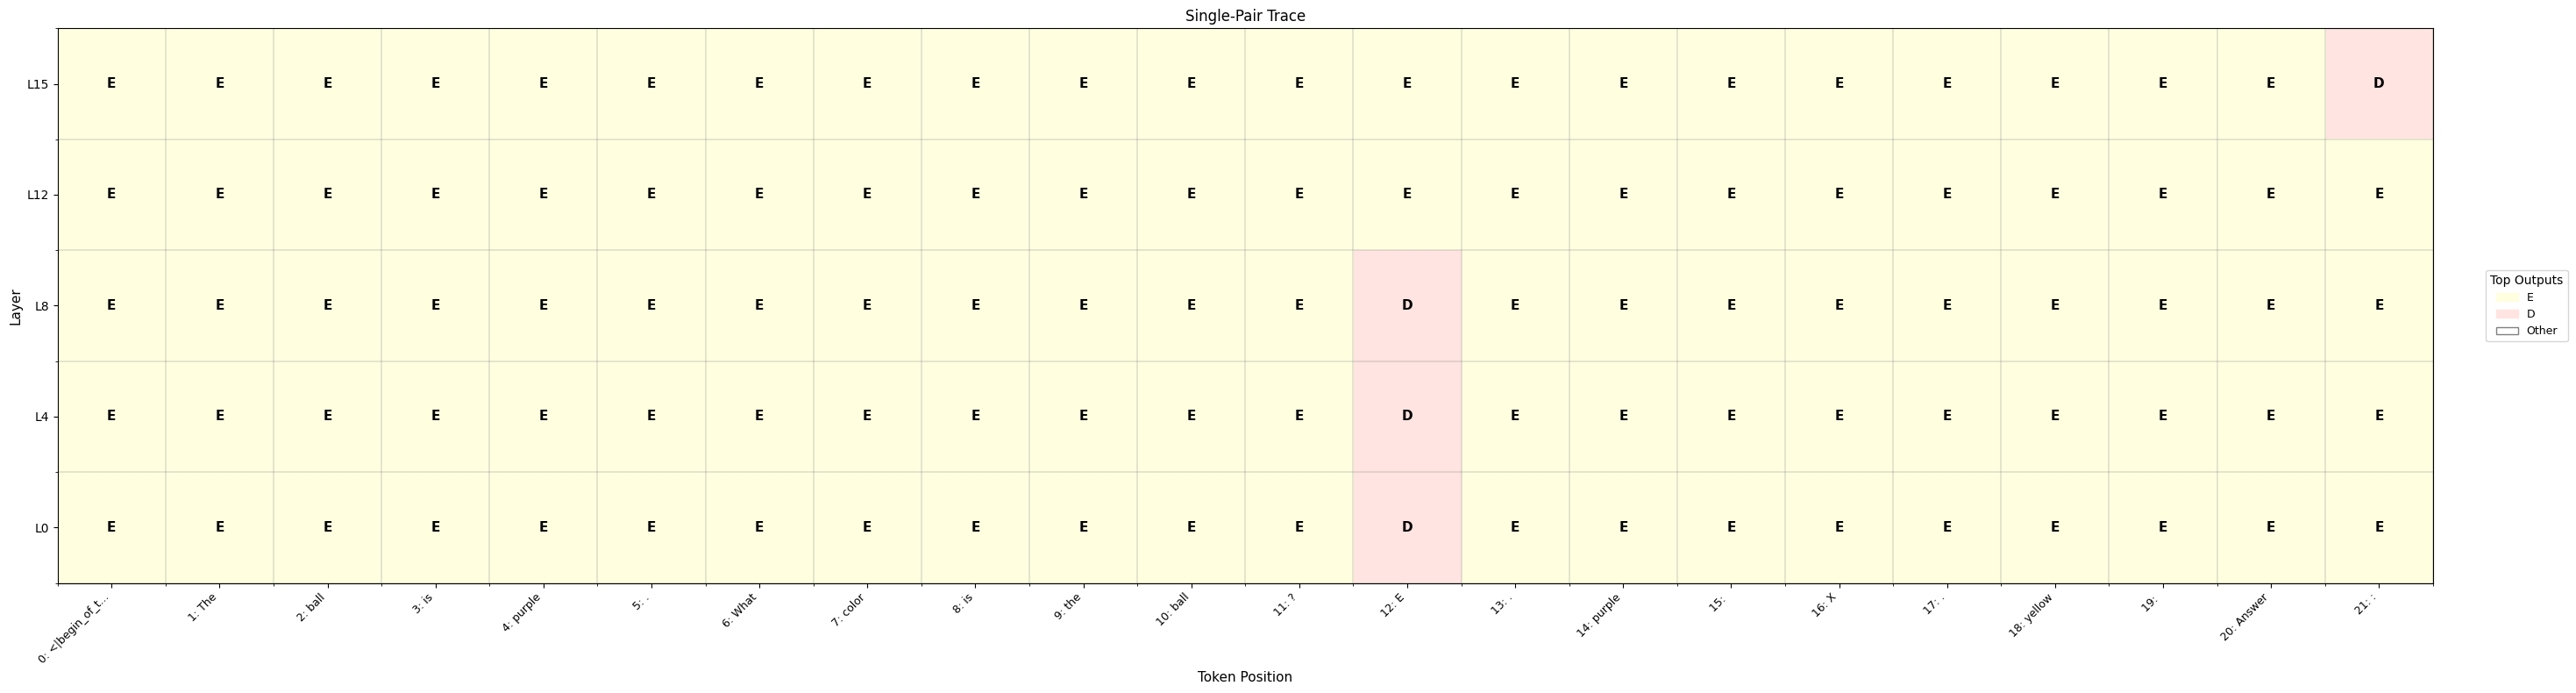

In [11]:
import json
from causalab.io.plots.string_heatmap import plot_single_pair_trace_heatmap

trace_path = os.path.join(artifact_dir, "single_pair_trace.json")
with open(trace_path) as f:
    saved_trace_data = json.load(f)

print(f"Base:           {saved_trace_data['prompt']}")
print(f"Counterfactual: {saved_trace_data['counterfactual_prompt']}")
print()

plot_single_pair_trace_heatmap(saved_trace_data, figure_format="png")

### Score heatmap

Unlike the single-pair trace which shows raw string outputs, the score heatmap aggregates over many examples. Each cell's score is the fraction of classes whose patched distribution is closer to the correct ground-truth reference than to any other class. A score of 1.0 means patching at that cell perfectly recovers the causal variable; chance-level is 1/n_classes.

Because `source_model` matches the target model in this demo (`llama32_1b_instruct` for both), this is a controlled validation: the cross-model heatmap must agree with what single-model patching would produce.


--- answer ---


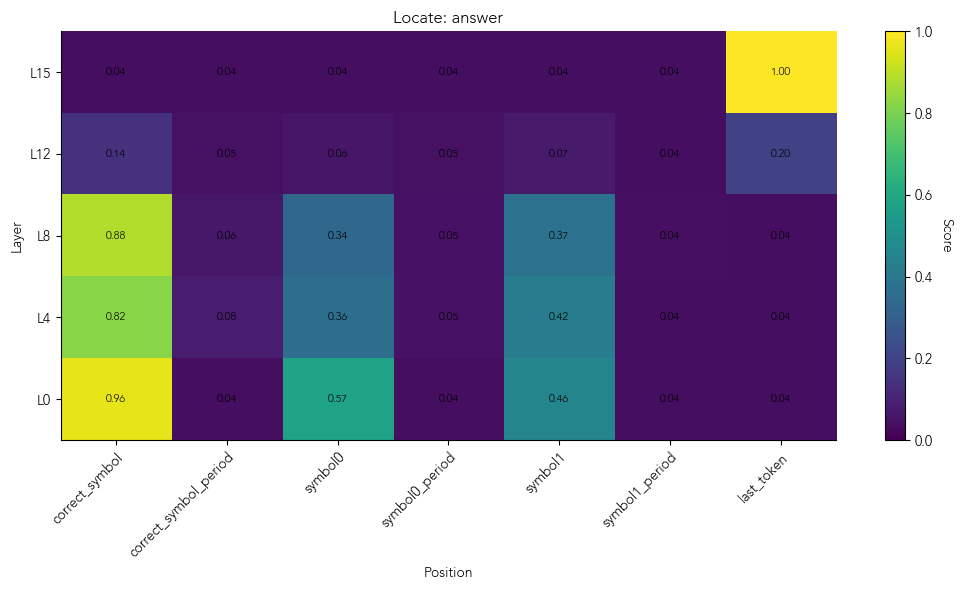

In [12]:
from IPython.display import Image, display

for var_name in sorted(os.listdir(artifact_dir)):
    var_dir = os.path.join(artifact_dir, var_name)
    if not os.path.isdir(var_dir):
        continue
    heatmap_path = os.path.join(var_dir, "heatmap.png")
    if os.path.exists(heatmap_path):
        print(f"\n--- {var_name} ---")
        display(Image(filename=heatmap_path))

## Takeaway

The single-pair trace from Section 1 gives intuition about one example; the score heatmap from Section 2 quantifies localization across the full dataset using a **real cross-model scan** — activations were collected from the source model and patched into the target model.

Together they answer: **which (layer, token_position) cell encodes the causal variable in a way that transfers across models?**

When `source_model` matches the target model (as in this demo, where both are `llama32_1b_instruct`), the cross-model result is a controlled validation: it must agree with the single-model baseline from Section 1. To run a genuine cross-model experiment, replace `source_model` with a different model of the same hidden dimension — only that config line changes.

**Note:** `mode: pairwise` is not supported when `source_model` is set. Always use `mode: centroid` for cross-model scans.

**What comes next:**
- `subspace` — find the low-dimensional linear directions that encode the variable within the best cell's activation space
- `activation_manifold` — map the geometric structure of how the variable is represented

For the full `locate` walkthrough including centroid vs pairwise mode, DBM binary masks, and multi-variable scans: `causalab/analyses/locate/demo.ipynb`.